In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("phamluhuynhmai/classroom-student-behaviors")

print("Downloaded to:", path)

Downloaded to: /kaggle/input/datasets/phamluhuynhmai/classroom-student-behaviors


In [3]:
# # Target folder in Drive
# target_folder = "/content/drive/MyDrive/Faizan  Bahi"

# # Create folder if not exists
# os.makedirs(target_folder, exist_ok=True)

# # Move dataset files
# shutil.move(path, target_folder)

# print("Dataset moved to:", target_folder)

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [5]:
import os
os.environ["PYTHONNOUSERSITE"] = "1"

# ثم نثبت numpy < 2
# !pip install -U "numpy<2" "scipy<1.14" "matplotlib<3.9" "seaborn" "scikit-learn<1.5" "torch" "torchvision" "deepface"

In [6]:
import os

dataset_path = "/kaggle/input/datasets/phamluhuynhmai/classroom-student-behaviors/Behaviors_Features"

if os.path.exists(dataset_path):
    print(f"Dataset found at: {dataset_path}")
    print(os.listdir(dataset_path))
else:
    print("Path not found! Scanning /kaggle/input to find correct path...")
    for root, dirs, files in os.walk('/kaggle/input'):
        level = root.replace('/kaggle/input', '').count(os.sep)
        if level <= 4:
            print('  ' * level + os.path.basename(root) + '/')


Dataset found at: /kaggle/input/datasets/phamluhuynhmai/classroom-student-behaviors/Behaviors_Features
['Thong Ke Data.txt', 'Turning_Around', 'Looking_Forward', 'Standing', 'Behaviors Data Version 1.xlsx', 'Reading', 'Raising_Hand', 'Writting', 'Sleeping']


In [7]:
# DeepFace removed — using torchvision ResNet50 for feature extraction
# (DeepFace weights cannot be downloaded on Kaggle's restricted internet)
!pip install -q opencv-python-headless


In [8]:
# Weight download cell removed — ResNet50 weights are built into torchvision
# and download automatically from PyTorch's CDN which Kaggle allows.
print('Using torchvision ResNet50 for feature extraction — no external weights needed.')


Using torchvision ResNet50 for feature extraction — no external weights needed.


In [9]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import os
import cv2


In [10]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [11]:
labels = ['Turning_Around','Looking_Forward','Standing','Reading','Raising_Hand','Writting','Sleeping']

dataset_dir = dataset_path  # set in Cell 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Load Dataset

In [12]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Torchvision (useful if you later work with images)
import torchvision
import torchvision.transforms as transforms

# Data utilities
from torch.utils.data import DataLoader, TensorDataset

# Numerical processing
import numpy as np

# Data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization (optional but useful)
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar for training
from tqdm import tqdm

In [13]:
images_paths = {}
for label in labels:
    images_paths[label] = []
    label_dir = os.path.join(dataset_dir, label)
    if not os.path.exists(label_dir):
        print(f"Warning: {label_dir} not found!")
        continue
    for root, _, files in os.walk(label_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                images_paths[label].append(os.path.join(root, file))



# Show count
for label in labels:
    print(label, len(images_paths[label]))

Turning_Around 46936
Looking_Forward 21269
Standing 7931
Reading 49799
Raising_Hand 16845
Writting 49046
Sleeping 60397


In [14]:
# Per-class 80/20 split — no balancing, each class keeps its full size
for label, paths in images_paths.items():
    print(f"{label}: {len(paths)} images")

Turning_Around: 46936 images
Looking_Forward: 21269 images
Standing: 7931 images
Reading: 49799 images
Raising_Hand: 16845 images
Writting: 49046 images
Sleeping: 60397 images


flatten

In [15]:
all_images = []
all_labels = []

for label in labels:
    all_images.extend(images_paths[label])
    all_labels.extend([label] * len(images_paths[label]))

label_to_int = {label: i for i, label in enumerate(labels)}
all_labels_int = [label_to_int[label] for label in all_labels]
print(label_to_int)
print(f"Total images: {len(all_images)}")

{'Turning_Around': 0, 'Looking_Forward': 1, 'Standing': 2, 'Reading': 3, 'Raising_Hand': 4, 'Writting': 5, 'Sleeping': 6}
Total images: 252223


In [16]:
train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, all_labels_int,
    test_size=0.20,
    stratify=all_labels_int,
    random_state=42
)

# Print per-class split counts
print(f"Train: {len(train_images)}  |  Test: {len(test_images)}\n")
for label in labels:
    idx = label_to_int[label]
    tr_count = train_labels.count(idx) if isinstance(train_labels, list) else (np.array(train_labels) == idx).sum()
    te_count = test_labels.count(idx) if isinstance(test_labels, list) else (np.array(test_labels) == idx).sum()
    print(f"{label:20s}  Train: {tr_count}  |  Test: {te_count}")

Train: 201778  |  Test: 50445

Turning_Around        Train: 37549  |  Test: 9387
Looking_Forward       Train: 17015  |  Test: 4254
Standing              Train: 6345  |  Test: 1586
Reading               Train: 39839  |  Test: 9960
Raising_Hand          Train: 13476  |  Test: 3369
Writting              Train: 39237  |  Test: 9809
Sleeping              Train: 48317  |  Test: 12080


## Feature Extraction

In [17]:
# ── Feature Extractor using ResNet50 (torchvision — no external weights needed) ──
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Load pretrained ResNet50 and remove final classification layer
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet = nn.Sequential(*list(resnet.children())[:-1])  # output: (batch, 2048, 1, 1)
resnet = resnet.to(DEVICE)
resnet.eval()
print(f'ResNet50 feature extractor loaded on {DEVICE}')
print('Output embedding size: 2048')

# Image transform pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def extract_features(image_paths, label_list, batch_size=64):
    """Extract ResNet50 features in batches for speed."""
    all_features = []
    all_valid_labels = []
    failed = 0

    for start in tqdm(range(0, len(image_paths), batch_size), desc='Extracting Features'):
        batch_paths  = image_paths[start:start + batch_size]
        batch_labels = label_list[start:start + batch_size]

        tensors = []
        valid_labels = []

        for path, lbl in zip(batch_paths, batch_labels):
            try:
                img = Image.open(path).convert('RGB')
                tensors.append(transform(img))
                valid_labels.append(lbl)
            except Exception as e:
                failed += 1

        if not tensors:
            continue

        batch_tensor = torch.stack(tensors).to(DEVICE)
        with torch.no_grad():
            feats = resnet(batch_tensor)          # (B, 2048, 1, 1)
            feats = feats.squeeze(-1).squeeze(-1) # (B, 2048)

        all_features.append(feats.cpu().numpy())
        all_valid_labels.extend(valid_labels)

    if failed > 0:
        print(f'  Skipped {failed} unreadable images')

    return np.vstack(all_features), np.array(all_valid_labels)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 315MB/s]


ResNet50 feature extractor loaded on cpu
Output embedding size: 2048


## save embeddings

In [18]:
print('\nExtracting TRAIN features...')
train_features, train_labels = extract_features(train_images, train_labels)
print(f'Train features shape: {train_features.shape}')

print('\nExtracting TEST features...')
test_features, test_labels = extract_features(test_images, test_labels)
print(f'Test features shape: {test_features.shape}')

# Save to /kaggle/working for reuse (optional)
save_dir = '/kaggle/working'
os.makedirs(save_dir, exist_ok=True)
# np.save(os.path.join(save_dir, 'train_features.npy'), train_features)
# np.save(os.path.join(save_dir, 'test_features.npy'),  test_features)
# np.save(os.path.join(save_dir, 'train_labels.npy'),   train_labels)
# np.save(os.path.join(save_dir, 'test_labels.npy'),    test_labels)
print(f'Done. Embeddings ready.')



Extracting TRAIN features...


Extracting Features: 100%|██████████| 3153/3153 [7:08:36<00:00,  8.16s/it]  


Train features shape: (201778, 2048)

Extracting TEST features...


Extracting Features: 100%|██████████| 789/789 [1:05:16<00:00,  4.96s/it]

Test features shape: (50445, 2048)
Done. Embeddings ready.


In [19]:
# Uncomment to load previously saved embeddings instead of re-extracting:
# save_dir = "/kaggle/working"
# print("\nLoading TRAIN features")
# train_features = np.load(os.path.join(save_dir, "train_features.npy"))
# train_labels   = np.load(os.path.join(save_dir, "train_labels.npy"))

# print("\nLoading TEST features")
# test_features = np.load(os.path.join(save_dir, "test_features.npy"))
# test_labels   = np.load(os.path.join(save_dir, "test_labels.npy"))
# print(f"Embeddings loaded from: {save_dir}")


In [28]:
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

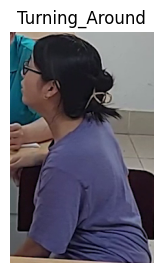

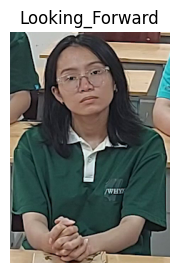

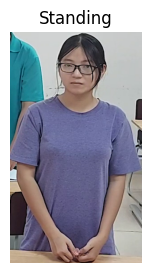

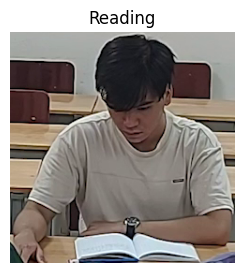

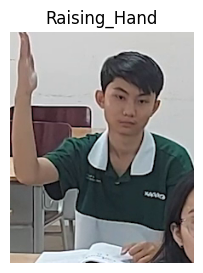

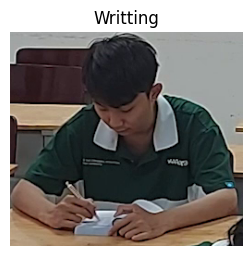

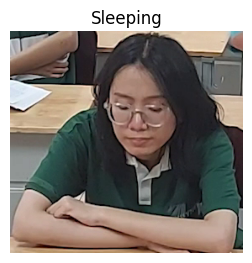

In [29]:
import cv2
import matplotlib.pyplot as plt
import random

for label in labels:
    sample = random.choice(images_paths[label])
    img = cv2.imread(sample)
    plt.figure(figsize=(3,3))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis("off")
    plt.show()


## pytorch Dataset

In [30]:
X_train = torch.tensor(train_features, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_test = torch.tensor(test_features, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

## Model

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

In [32]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, h, w = x.size()
        y = F.adaptive_avg_pool2d(x, 1).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

In [33]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels)
        )

    def forward(self, x):
        b, c, h, w = x.size()

        avg = F.adaptive_avg_pool2d(x, 1).view(b, c)
        maxp = F.adaptive_max_pool2d(x, 1).view(b, c)

        attn = torch.sigmoid(self.mlp(avg) + self.mlp(maxp))
        return x * attn.view(b, c, 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxp, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg, maxp], dim=1)
        attn = torch.sigmoid(self.conv(x_cat))
        return x * attn


class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

In [35]:
class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

In [38]:
class FeatureTransformerModel(nn.Module):
    def __init__(self, input_dim=2048, num_classes=7):
        super().__init__()
        self.feature_proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3)
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=512,
            nhead=8,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )
        self.attn_pool = AttentionPooling(512)
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.feature_proj(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = self.attn_pool(x)
        x = self.classifier(x)
        return x

In [39]:
model = FeatureTransformerModel(input_dim=2048, num_classes=7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print('Model loaded on:', device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')


Model loaded on: cpu
Trainable parameters: 7,421,960


In [40]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")

# model = BehaviorClassifier(input_dim=128, num_classes=7).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

## training

In [41]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
best_val_acc = 0
patience_counter = 0
best_weights = None
patience = 10

In [42]:
num_epochs = 50

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_acc = train_correct / train_total
    train_losses.append(epoch_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            val_running_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == y).sum().item()
            val_total += y.size(0)

    val_loss = val_running_loss / len(test_loader.dataset)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}  Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch [1/50]  Train Loss: 0.4775  Val Loss: 0.4588  Train Acc: 0.9917  Val Acc: 0.9966
Epoch [2/50]  Train Loss: 0.4631  Val Loss: 0.4547  Train Acc: 0.9970  Val Acc: 0.9978
Epoch [3/50]  Train Loss: 0.4603  Val Loss: 0.4506  Train Acc: 0.9978  Val Acc: 0.9993
Epoch [4/50]  Train Loss: 0.4577  Val Loss: 0.4499  Train Acc: 0.9986  Val Acc: 0.9992
Epoch [5/50]  Train Loss: 0.4570  Val Loss: 0.4507  Train Acc: 0.9988  Val Acc: 0.9996
Epoch [6/50]  Train Loss: 0.4556  Val Loss: 0.4489  Train Acc: 0.9992  Val Acc: 0.9995
Epoch [7/50]  Train Loss: 0.4553  Val Loss: 0.4502  Train Acc: 0.9992  Val Acc: 0.9997
Epoch [8/50]  Train Loss: 0.4542  Val Loss: 0.4499  Train Acc: 0.9994  Val Acc: 0.9996
Epoch [9/50]  Train Loss: 0.4534  Val Loss: 0.4502  Train Acc: 0.9995  Val Acc: 0.9994
Epoch [10/50]  Train Loss: 0.4528  Val Loss: 0.4490  Train Acc: 0.9996  Val Acc: 0.9997
Epoch [11/50]  Train Loss: 0.4521  Val Loss: 0.4497  Train Acc: 0.9996  Val Acc: 0.9994
Epoch [12/50]  Train Loss: 0.4519  Val Lo

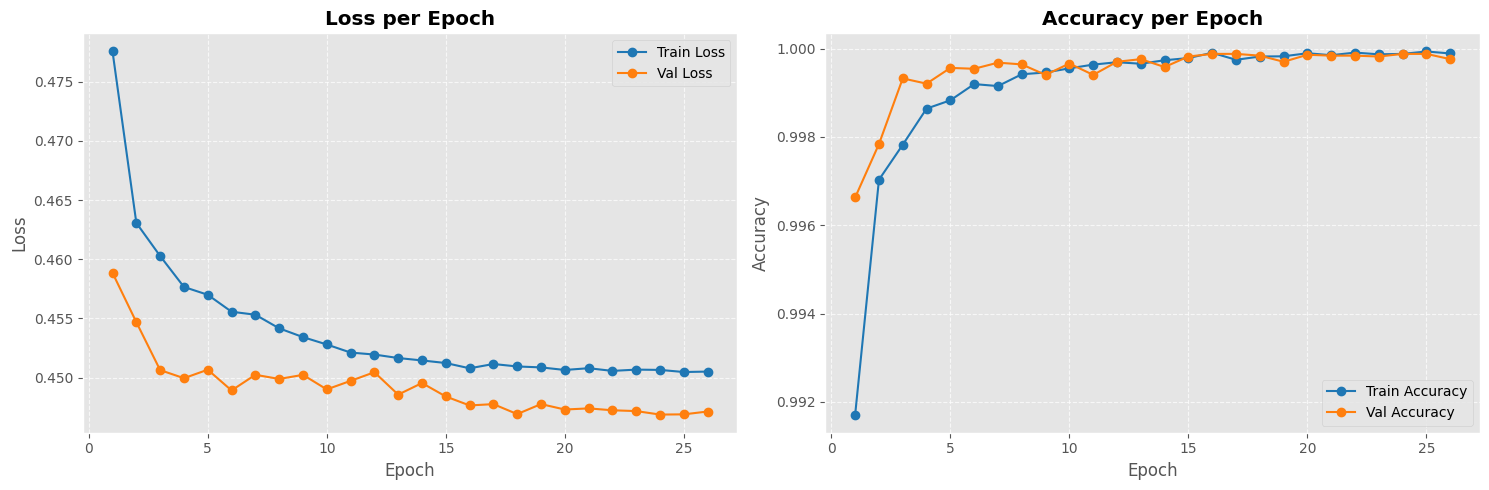

In [43]:
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(train_losses) + 1)

# Loss plot — train & validation
ax1.plot(epochs, train_losses, marker='o', linestyle='-', color='#1f77b4', label='Train Loss')
ax1.plot(epochs, val_losses, marker='o', linestyle='-', color='#ff7f0e', label='Val Loss')
ax1.set_title('Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy plot — train & validation
ax2.plot(epochs, train_accuracies, marker='o', linestyle='-', color='#1f77b4', label='Train Accuracy')
ax2.plot(epochs, val_accuracies, marker='o', linestyle='-', color='#ff7f0e', label='Val Accuracy')
ax2.set_title('Accuracy per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [44]:
model.load_state_dict(best_weights)
torch.save(model.state_dict(), "student_behavior_classifier_pytorch.pth")
print(f" Best model saved! Best Test Accuracy: {best_val_acc:.4f}")


 Best model saved! Best Test Accuracy: 0.9999


### Evaluation

In [45]:
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y_true = y.cpu().numpy()
        outputs = model(x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_true)

all_preds = np.array(all_preds)
all_true = np.array(all_true)
print(classification_report(test_labels, all_preds, target_names=labels))

                 precision    recall  f1-score   support

 Turning_Around       1.00      1.00      1.00      9387
Looking_Forward       1.00      1.00      1.00      4254
       Standing       1.00      1.00      1.00      1586
        Reading       1.00      1.00      1.00      9960
   Raising_Hand       1.00      1.00      1.00      3369
       Writting       1.00      1.00      1.00      9809
       Sleeping       1.00      1.00      1.00     12080

       accuracy                           1.00     50445
      macro avg       1.00      1.00      1.00     50445
   weighted avg       1.00      1.00      1.00     50445



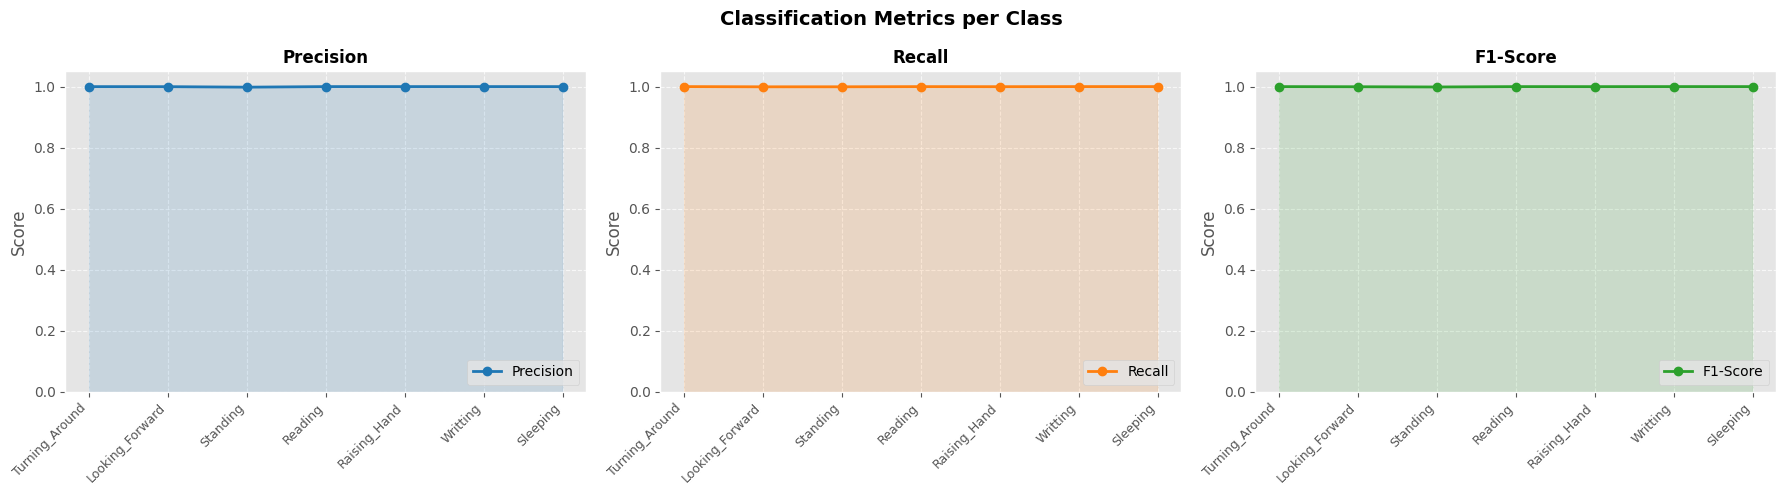

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y_true = y.cpu().numpy()
        outputs = model(x)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(y_true)
all_preds = np.array(all_preds)
all_true = np.array(all_true)
report = classification_report(test_labels, all_preds, target_names=labels, output_dict=True)
precision = [report[label]['precision'] for label in labels]
recall    = [report[label]['recall']    for label in labels]
f1        = [report[label]['f1-score']  for label in labels]
# livelossplot-style: side-by-side line plots with markers
plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Classification Metrics per Class', fontsize=14, fontweight='bold')
x = np.arange(len(labels))
plots = [
    ('Precision', precision, '#1f77b4'),
    ('Recall',    recall,    '#ff7f0e'),
    ('F1-Score',  f1,        '#2ca02c'),
]
for ax, (title, values, color) in zip(axes, plots):
    ax.plot(x, values, marker='o', color=color, linewidth=2, markersize=6, label=title)
    ax.fill_between(x, values, alpha=0.15, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

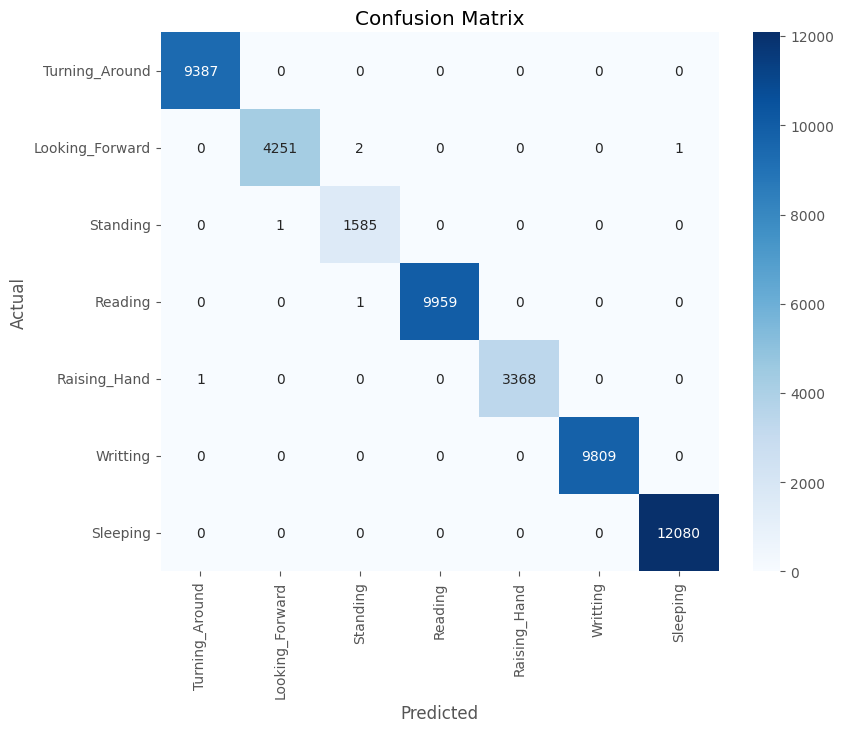

In [48]:
cm = confusion_matrix(test_labels, all_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# num_samples = 2

# max_len = min(len(test_images), len(test_labels), len(all_preds))
# indices = random.sample(range(max_len), min(num_samples, max_len))

# plt.figure(figsize=(16, 10))

# for i, idx in enumerate(indices):
#     img_path = test_images[idx]

#     true_label = labels[int(test_labels[idx])]   # ground truth from original split
#     pred_label = labels[int(all_preds[idx])]      # model prediction
#     is_correct = (int(test_labels[idx]) == int(all_preds[idx]))

#     img = cv2.imread(img_path)
#     if img is None:
#         continue

#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     plt.subplot(3, 4, i + 1)
#     plt.imshow(img_rgb)

#     color = 'green' if is_correct else 'red'
#     status = "✓ Correct" if is_correct else "✗ Wrong"
#     plt.title(
#         f"True:  {true_label}\nPred: {pred_label}\n{status}",
#         fontsize=9,
#         color=color,
#         fontweight='bold'
#     )
#     plt.axis("off")

# plt.tight_layout()
# plt.suptitle("Test Data Results", y=1.02, fontsize=14)
# plt.show()